In [5]:
import numpy as np
import matplotlib.pyplot as plt
%run plot.py

### Function for the random step
create the random increments of a time series as random walk

$DX$ is the standard deviation, $bias$ is the constant average of the step

In [13]:
# random seed for reproducibility
np.random.seed(12345)

# function for the random step, using lambda construction
# int() for cleaner look and for mimiking a detector with finite resolution
jump = lambda drift, stdev: [int(np.random.normal(drift,stdev)), int(np.random.normal(drift,stdev))]

for i in range(10):
    print(jump(5,50))

[-5, 28]
[-20, -22]
[103, 74]
[9, 19]
[43, 67]
[55, -59]
[18, 16]
[72, 49]
[-95, -13]
[88, -16]


definiamo la lambda function jump come un salto randominco con drift.
Si può schematizzare come una particella che salta avanti o indietro in modo casuale distribuito gaussianamente con deviazione standard 50.
Si ha un drift di 5 quindi in media la velocità della particella sarà appunto 5

### Function for the added pattern
to add to part of a time series, over $z$ bins, with amplitude $a$

In [24]:
def pattern(i,z_1,a_1, z_2,a_2):
    return np.array([int(a_1*np.sin((np.pi*i)/z_1)), int(a_2*np.sin((np.pi*i)/z_2))])

(10000, 60, 2)
[[   0.    0.]
 [  -5.   28.]
 [ -25.    6.]
 [  78.   80.]
 [  87.   99.]
 [ 130.  166.]
 [ 185.  107.]
 [ 203.  123.]
 [ 275.  172.]
 [ 180.  159.]
 [ 268.  143.]
 [ 247.  171.]
 [ 414.  125.]
 [ 391.  136.]
 [ 411.  167.]
 [ 416.  239.]
 [ 386.  203.]
 [ 273.  115.]
 [ 235.  148.]
 [ 177.  158.]
 [ 129.  179.]
 [  17.  175.]
 [ -55.  132.]
 [-115.  151.]
 [ -92.  119.]
 [ -71.  191.]
 [ -63.  208.]
 [ -59.  263.]
 [  12.  223.]
 [ -60.  229.]
 [ -18.  201.]
 [  30.  205.]
 [  37.  243.]
 [  84.  201.]
 [  87.   91.]
 [  60.   36.]
 [  -1.   94.]
 [  40.  133.]
 [  95.  113.]
 [  69.   72.]
 [  38.   88.]
 [  45.   36.]
 [  90.   62.]
 [ 145.  158.]
 [ 101.  205.]
 [ 100.  255.]
 [ 114.  368.]
 [ 114.  473.]
 [ 120.  517.]
 [ 130.  485.]
 [ 164.  497.]
 [  91.  474.]
 [  94.  433.]
 [  75.  436.]
 [ 134.  490.]
 [ 110.  574.]
 [  89.  601.]
 [ 140.  528.]
 [  94.  513.]
 [ 110.  509.]] 0
[[ 148.  432.]
 [  41.  379.]
 [  63.  419.]
 [  55.  418.]
 [  65.  393.]
 [  50.

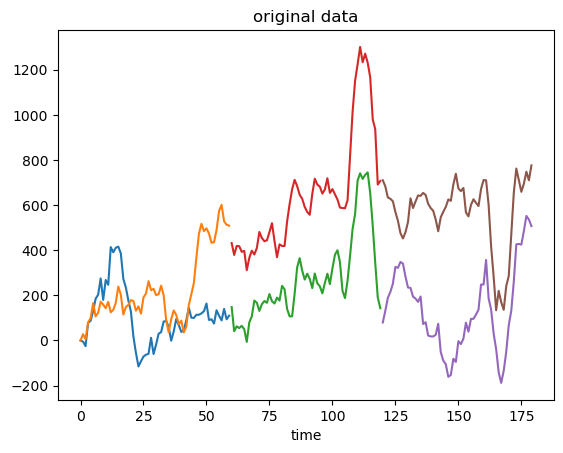

In [25]:

## random seed for reproducibility
np.random.seed(12345)

# pattern parameters: Z=nr of steps, A=amplitude
Z_1=12
A_1=500
Z_2=12
A_2=500
# number of data samples
N=10000
# size of each sample of the timeseries
L=60
# step parameters: introduce small positive bias
DX = 50 # standard deviation of the random step
bias = 5  # bias to make the random walk drift in the positive direction

y = [0] * N # initialize class labels with zeros
x = [[[0], [0]] * L for i in range(N)] # initialize timeseries with zeros


x = np.zeros((N, L, 2))
print(x.shape)
for i in range(N):
    if i>0:
        x[i][0] = x[i-1][-1] + jump(bias,DX) # first step of the new sample starts from the last point of the previous one
        
    for j in range(1,L):
        x[i][j] = x[i][j-1] + jump(bias,DX) # random walk with bias

    y[i] = i%3 # assign class labels (0,1,2)
    ##y[i] = random.randint(0,2) # random assingment
    if y[i]>0:
        j0 = np.random.randint(0,L-1-Z_1) # random starting point for the pattern
        ###print(i,j0,j1)
        sign = 3-2*y[i] # sign of the pattern: + for class 1, - for class 2
        for j in range(Z_1):
            x[i][j0+j] += sign*pattern(j,Z_1,A_1,Z_2,A_2) # add pattern to the timeseries

for i in range(min(3,N)):
    print(x[i],y[i])


Show_data(x,L,"original data")

### Save data on file

In [9]:
# command in linux
!mkdir DATA
str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'
print(str0)

fname='DATA/x_'+str0
np.savetxt(fname,x,fmt="%d")
fname='DATA/y_'+str0
np.savetxt(fname,y,fmt="%d")

ts_L60_Z12_A500_DX50_bias5_N10000.dat
